# SQL DataBase

In [10]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Loading CVS into DuckDB
See associate sql database file (database.sql) to get a better understanding of the tables. File is redundant since we alr create tables on ipynb but it gives good idea of column names and you can query them if needed.

In [ ]:
connection = duckdb.connect(database=':memory:')

connection.execute("""
CREATE TABLE housing_data AS
SELECT * FROM read_csv_auto('../data/housing_units_all.csv', header=True)

""")

connection.execute("""
CREATE TABLE population AS
SELECT * FROM read_csv_auto('../data/population_clean.csv', header=True)
""")

connection.execute("""
CREATE TABLE debt AS
SELECT * FROM read_csv_auto('../data/debt_2003_2025 _clean.csv', header=True)
""")

connection.execute("""
CREATE TABLE property_tax AS
SELECT * FROM read_csv_auto('../data/PropertyTax_DataSet_Cleaned.csv', header=True)
""")

connection.execute("""
CREATE TABLE median_price AS
SELECT * FROM read_csv_auto('../data/MedianPricesofExistingDetachedHomesHistoricalData - Median Price.csv', header=True, skip=1)
""")

# Query debt data
## Querying from 2003 to 2025

It got a bit nonsensical to query every debt type so I'm only going to include the top 3 which were decided to feauture/impact more (check small neural network & tree): Mortgage, HE_Revolving, and Auto Loans (student loans is in there because I got lazy and decided to include it at that point). To make up for it I included total and avg debt queries. Note: Does not include CA_Lag which was a BIG factor in regression.

In [157]:
connection.execute("""
SELECT
    CAST('20' || SUBSTR(quarter, 1, 2) AS INT) AS year,
    quarter,
    Mortgage,
    "Credit Card"   AS credit_card,
    "Student Loan"  AS student_loan,
    "Auto Loan"     AS auto_loan,
    "HE Revolving"  AS he_revolving
FROM debt
WHERE CAST('20' || SUBSTR(quarter, 1, 2) AS INT) BETWEEN 2003 AND 2025;
""").fetch_df()

# # showing total debt by year
# connection.execute("""
# SELECT 
#     CAST('20' || SUBSTR(quarter, 1, 2) AS INT) AS year,
#     SUM(Mortgage)       AS total_mortgage,
#     SUM("Credit Card")  AS total_credit_card,
#     SUM("Student Loan") AS total_student_loan,
#     SUM("Auto Loan")    AS total_auto_loan,
#     SUM("HE Revolving") AS total_he_revolving
# FROM debt
# GROUP BY year
# ORDER BY year;
# """).fetchdf()




,year,quarter,Mortgage,credit_card,student_loan,auto_loan,he_revolving
0,2003,03:Q1,4.94,0.690,0.240,0.640,0.240
1,2003,03:Q2,5.08,0.690,0.240,0.620,0.260
2,2003,03:Q3,5.18,0.690,0.250,0.680,0.270
3,2003,03:Q4,5.66,0.700,0.250,0.700,0.300
4,2004,04:Q1,5.84,0.700,0.260,0.720,0.330
...,...,...,...,...,...,...,...
86,2024,24:Q3,12.59,1.166,1.606,1.644,0.387
87,2024,24:Q4,12.61,1.211,1.615,1.655,0.396
88,2025,25:Q1,12.80,1.182,1.631,1.642,0.402
89,2025,25:Q2,12.94,1.209,1.638,1.655,0.411


## avg debt by year

In [ ]:
connection.execute("""
SELECT
    CAST('20' || SUBSTR(quarter, 1, 2) AS INT) AS year,
    AVG(Mortgage)       AS avg_mortgage,
    AVG("Credit Card")  AS avg_credit_card,
    AVG("Student Loan") AS avg_student_loan,
    AVG("Auto Loan")    AS avg_auto_loan,
    AVG("HE Revolving") AS avg_he_revolving
FROM debt
GROUP BY year
ORDER BY year;
""").fetchdf()


,year,avg_mortgage,avg_credit_card,avg_student_loan,avg_auto_loan,avg_he_revolving
0,2003,5.215000,0.69250,0.245000,0.660000,0.267500
1,2004,6.095000,0.70750,0.300000,0.735000,0.400000
2,2005,6.805000,0.72500,0.375000,0.780000,0.535000
3,2006,7.870000,0.74500,0.450000,0.807500,0.592500
4,2007,8.790000,0.80500,0.525000,0.810000,0.627500
5,2008,9.262500,0.85500,0.605000,0.805000,0.685000
6,2009,8.995000,0.81750,0.687500,0.742500,0.710000
7,2010,8.647500,0.74000,0.777500,0.705000,0.680000
8,2011,8.432500,0.69500,0.857500,0.720000,0.632500
9,2012,8.100000,0.67500,0.935000,0.760000,0.582500


## Querying mortgage debt

In [25]:
# descriptive stats for mortgage debt data
connection.execute("""
SELECT
    AVG(Mortgage)       AS avg_mortgage,
    MIN(Mortgage)       AS min_mortgage,
    MAX(Mortgage)       AS max_mortgage,
    STDDEV(Mortgage)    AS stddev_mortgage
FROM debt;
""").fetchdf()       

,avg_mortgage,min_mortgage,max_mortgage,stddev_mortgage
0,8.982967,4.94,13.07,1.854273


# ploting mortgage debt over time (2003-2025)

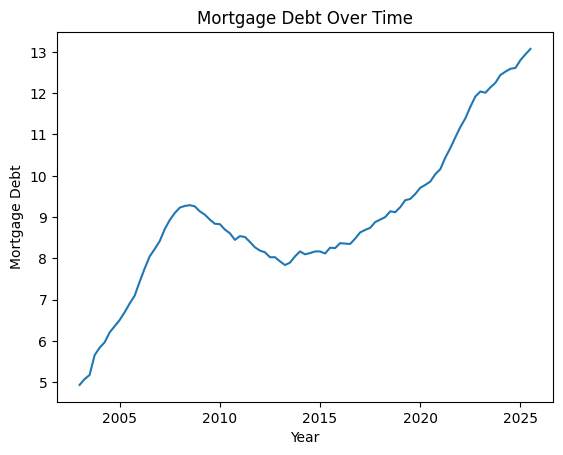

In [26]:
debt_data = connection.execute("""
SELECT
    CAST('20' || SUBSTR(quarter, 1, 2) AS INT) AS year,
    CAST(RIGHT(quarter, 1) AS INT) AS quarter
    ,Mortgage
FROM debt
""").fetchdf()
debt_data['time'] = debt_data['year'] + (debt_data['quarter'] - 1) / 4
plt.plot(debt_data['time'], debt_data['Mortgage'])
plt.xlabel('Year')
plt.ylabel('Mortgage Debt')
plt.title('Mortgage Debt Over Time')
plt.show()

# Total debt descriptive stats 

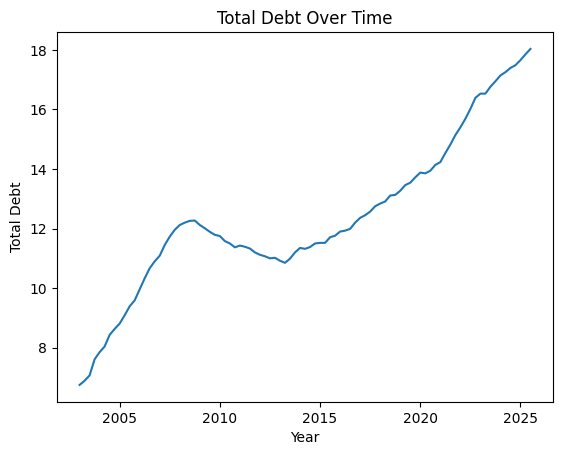

In [65]:
# Total debt descriptive stats for all debt types

# got lazy so if you want the descriptive stats to show just comment the plot code and add fetchdf() at the end of the query

# connection.execute("""
# SELECT
#     AVG(Mortgage + "Credit Card" + "Student Loan" + "Auto Loan" + "HE Revolving") AS avg_total_debt,
#     MIN(Mortgage + "Credit Card" + "Student Loan" + "Auto Loan" + "HE Revolving") AS min_total_debt,
#     MAX(Mortgage + "Credit Card" + "Student Loan" + "Auto Loan" + "HE Revolving") AS max_total_debt,
#     STDDEV(Mortgage + "Credit Card" + "Student Loan" + "Auto Loan" + "HE Revolving") AS stddev_total_debt
# FROM debt;
# """)

# plotting total debt over time
debt_data = connection.execute("""
SELECT
    CAST('20' || SUBSTR(quarter, 1, 2) AS INT) AS year,
    CAST(RIGHT(quarter, 1) AS INT) AS quarter,
    (Mortgage + "Credit Card" + "Student Loan" + "Auto Loan" + "HE Revolving") AS total_debt
FROM debt
""").fetchdf()

debt_data['time'] = debt_data['year'] + (debt_data['quarter'] - 1) / 4
plt.plot(debt_data['time'], debt_data['total_debt'])
plt.xlabel('Year')
plt.ylabel('Total Debt')
plt.title('Total Debt Over Time')
plt.show()

## student loan stats & plot 

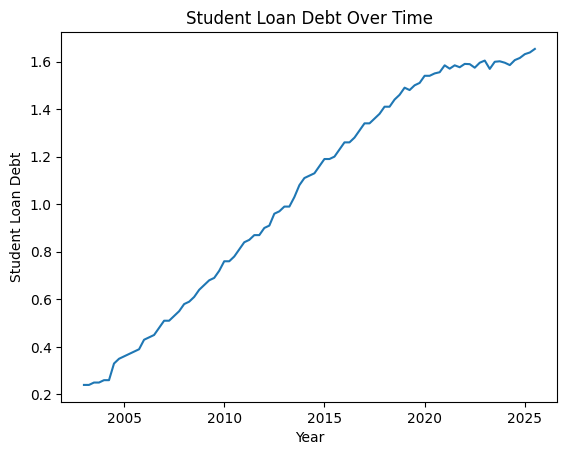

In [32]:
# descriptive stats for student loan debt data
connection.execute("""
SELECT
    AVG("Student Loan")       AS avg_student_loan,
    MIN("Student Loan")       AS min_student_loan,
    MAX("Student Loan")       AS max_student_loan,
    STDDEV("Student Loan")    AS stddev_student_loan
FROM debt;
""")

# plotting student loan debt over time

debt_data = connection.execute("""
SELECT
    CAST('20' || SUBSTR(quarter, 1, 2) AS INT) AS year,
    CAST(RIGHT(quarter, 1) AS INT) AS quarter,
    "Student Loan"                 AS student_loan
FROM debt
""").fetchdf()
debt_data['time'] = debt_data['year'] + (debt_data['quarter'] - 1) / 4
plt.plot(debt_data['time'], debt_data['student_loan'])
plt.xlabel('Year')
plt.ylabel('Student Loan Debt')
plt.title('Student Loan Debt Over Time')
plt.show()


## He Revolving debt data

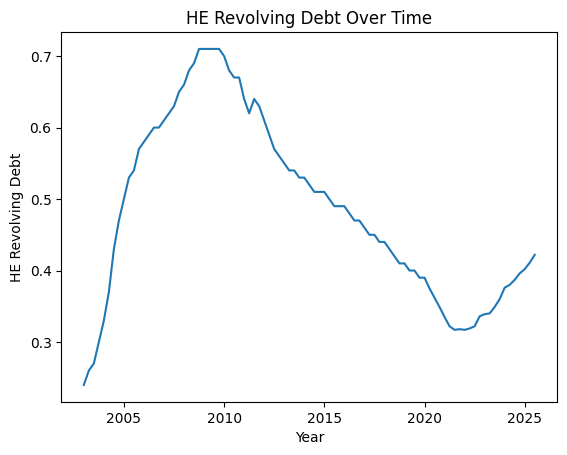

In [35]:
# HE Revolving descriptive stats
connection.execute("""
SELECT
    AVG("HE Revolving")       AS avg_he_revolving,
    MIN("HE Revolving")       AS min_he_revolving,
    MAX("HE Revolving")       AS max_he_revolving,
    STDDEV("HE Revolving")    AS stddev_he_revolving
FROM debt;
""").fetchdf()

# plotting HE Revolving debt over time
debt_data = connection.execute("""
SELECT
    CAST('20' || SUBSTR(quarter, 1, 2) AS INT) AS year,
    CAST(RIGHT(quarter, 1) AS INT) AS quarter,
    "HE Revolving"                 AS he_revolving
FROM debt
""").fetchdf()
debt_data['time'] = debt_data['year'] + (debt_data['quarter'] - 1) / 4
plt.plot(debt_data['time'], debt_data['he_revolving'])
plt.xlabel('Year')
plt.ylabel('HE Revolving Debt')
plt.title('HE Revolving Debt Over Time')
plt.show()

## Auto Loan debt querying 

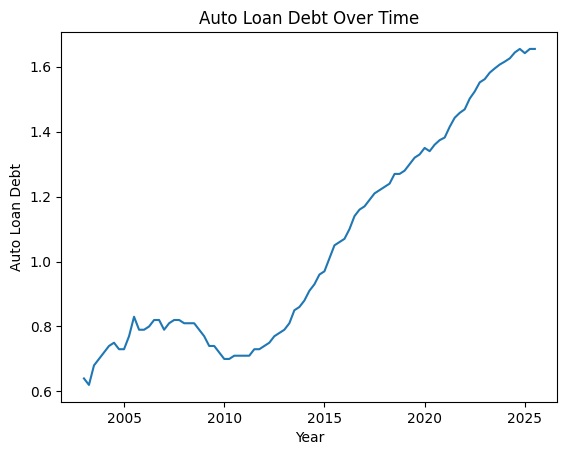

In [47]:
# Auto Loan descriptive stats
connection.execute("""
SELECT
    AVG("Auto Loan")       AS avg_auto_loan,
    MIN("Auto Loan")       AS min_auto_loan,
    MAX("Auto Loan")       AS max_auto_loan,
    STDDEV("Auto Loan")    AS stddev_auto_loan
FROM debt;
""")

# plotting Auto Loan debt over time
debt_data = connection.execute("""
SELECT
    CAST('20' || SUBSTR(quarter, 1, 2) AS INT) AS year,
    CAST(RIGHT(quarter, 1) AS INT) AS quarter,
    "Auto Loan"                 AS auto_loan
FROM debt
""")
debt_data = debt_data.fetchdf()
debt_data['time'] = debt_data['year'] + (debt_data['quarter'] - 1) / 4
plt.plot(debt_data['time'], debt_data['auto_loan'])
plt.xlabel('Year')
plt.ylabel('Auto Loan Debt')
plt.title('Auto Loan Debt Over Time')
plt.show()


# querying housing data

## querying housing data across all areas by year (Top 5 shown)


In [56]:
connection.execute("""
SELECT * FROM housing_data
LIMIT 5
                 
""").fetch_df()

,Area,2000,2001,2002,2003,2004,2005,2006,2007,2008,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,Alameda County,541385,546269,550054,553821,558677,564447,569206,575668,579064,...,593622,596473,600623,605146,610046,623350,629792,637701,644826,650523
1,Alpine County,1519,1540,1589,1646,1670,1688,1701,1726,1755,...,1774,1777,1778,1780,1785,1543,1545,1545,1548,1548
2,Amador County,15166,15456,15722,16046,16526,17042,17477,17724,17891,...,18164,18176,18203,18248,18310,18816,18915,19033,19127,19229
3,Butte County,85759,86745,87691,88729,90373,92258,93812,94841,95524,...,98018,98567,99177,99711,85787,90238,91037,92615,94290,95781
4,Calaveras County,22988,23429,23991,24527,25240,26097,26975,27473,27751,...,28299,27830,27988,28139,28239,27454,27583,27687,27778,27873


## querying to show only California housing units years

In [ ]:
connection.execute("""
SELECT *
FROM housing_data
WHERE Area = 'California'
""").fetch_df()


,Area,2000,2001,2002,2003,2004,2005,2006,2007,2008,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,California,12250974,12400531,12552174,12721844,12920250,13128316,13334467,13491056,13596788,...,13959093,14036744,14127586,14214078,14292093,14417494,14524995,14642752,14762262,14877904


## descriptive stats for CA

In [ ]:
# descriptive stats for CA housing units

cal_df = connection.execute("""
SELECT *
FROM housing_data
WHERE Area = 'California'
""").fetch_df()

cal_df = cal_df.melt(id_vars=['Area'], var_name='Year', value_name='Housing Units')
cal_df['Housing Units'] = cal_df['Housing Units'].astype(float)

cal_df.describe()

,Housing Units
count,2.500000e+01
mean,1.371222e+07
std,7.308634e+05
min,1.225097e+07
25%,1.333447e+07
50%,1.377232e+07
75%,1.421408e+07
max,1.487790e+07


## plotting CA housing units accross years 


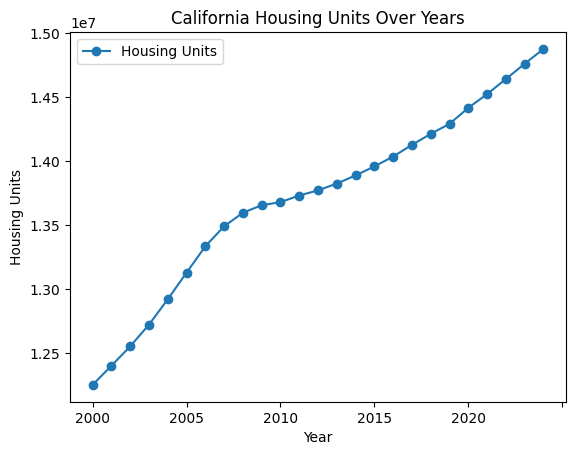

In [ ]:
# Plotting only California housing units across years

cal_df.plot(x='Year', y='Housing Units', kind='line', marker='o')
plt.title('California Housing Units Over Years')
plt.xlabel('Year')
plt.ylabel('Housing Units')
plt.show()

# Querying population data
## population growth rate comparing each year to previous year


In [70]:
connection.execute("""
SELECT * FROM population
WHERE year BETWEEN 2000 AND 2020
ORDER BY year;
""").fetchdf()

pop_data = connection.execute("""
SELECT
                   year,
                   population,
                   LAG(population) OVER (ORDER BY year) AS previous_population,
                   ROUND(((population - LAG(population) OVER (ORDER BY year)) * 100.0) / LAG(population) OVER (ORDER BY year), 2) AS growth_rate_percentage
FROM population 
WHERE year BETWEEN 2000 AND 2020
ORDER BY year;
""").fetchdf()

## plotting % growth rate for population

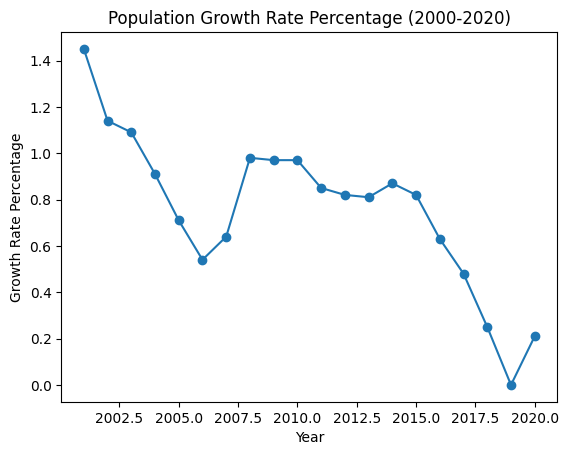

In [ ]:
plt.plot(pop_data['year'], pop_data['growth_rate_percentage'], marker='o')
plt.title('Population Growth Rate Percentage (2000-2020)')
plt.xlabel('Year')
plt.ylabel('Growth Rate Percentage')
plt.show()

# Querying Property Taxes

In [18]:
connection.execute("""
SELECT * FROM property_tax
LIMIT 10;
""").fetchdf()

,Entity Name,Entity ID,Fiscal Year,Secured_Net Taxable Value_Countywide Property Taxes,Unsecured_Net Taxable Value_Countywide Property Taxes,Secured_Tax Rate 1%_Countywide Property Taxes,Unsecured_Tax Rate 1%_Countywide Property Taxes,Tax Rate 1%: Homeowners Property Tax Reimbursement (HOPTR),Total_Countywide Property Taxes
0,Alameda,117,2019,277914233900,13669817723,2779142339,136698177,17273350,2933113866
1,Alpine,118,2019,710871500,42200190,7108715,422002,15624,7546341
2,Amador,119,2019,5242246166,74907168,52422462,749072,596754,53768288
3,Butte,120,2019,22124812484,1159408507,221248125,11594085,2675053,235517263
4,Calaveras,121,2019,7189420543,108152546,71894205,1081525,744665,71983302
5,Colusa,122,2019,3785190841,290922670,37851908,2909227,227113,40945866
6,Contra Costa,123,2019,201827360949,5490012251,2018273609,54900123,12734507,2085908239
7,Del Norte,124,2019,1818090984,39371328,18180910,393713,310475,18885098
8,El Dorado,125,2019,32903819099,576502030,329038191,5765020,2844645,337647856
9,Fresno,126,2019,78218515406,3519685648,782185154,35196856,6676069,822636587


## SD Fiscal Year 


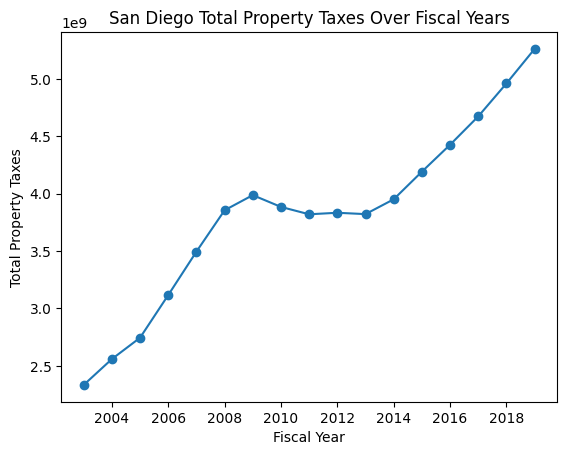

In [93]:
# querying for San Diego property tax data
sd_prop = connection.execute("""
SELECT
    "Fiscal Year",
    "Secured_Net Taxable Value_Countywide Property Taxes",
    "Unsecured_Net Taxable Value_Countywide Property Taxes",
    "Secured_Tax Rate 1%_Countywide Property Taxes",
    "Unsecured_Tax Rate 1%_Countywide Property Taxes",
    "Tax Rate 1%: Homeowners Property Tax Reimbursement (HOPTR)",
    "Total_Countywide Property Taxes"
FROM property_tax
WHERE "Entity Name" = 'San Diego';
""").fetchdf()

# plot San Diego Total Property Taxes over Fiscal Years
plt.plot(sd_prop['Fiscal Year'], sd_prop['Total_Countywide Property Taxes'], marker='o')
plt.title('San Diego Total Property Taxes Over Fiscal Years')
plt.xlabel('Fiscal Year')
plt.ylabel('Total Property Taxes')
plt.show()


## plotting for Los Angeles property tax data


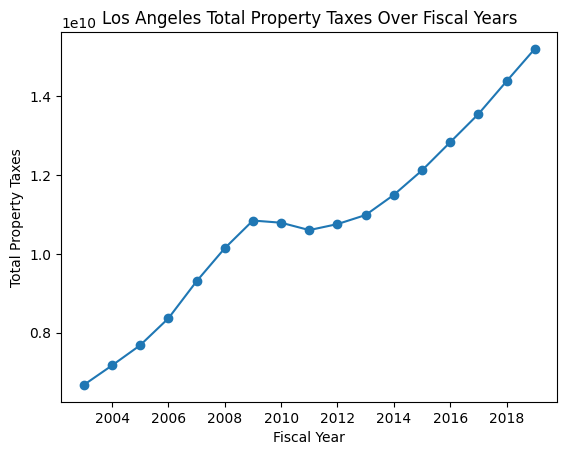

In [ ]:
la_prop = connection.execute("""
SELECT
    "Fiscal Year",
    "Total_Countywide Property Taxes"
FROM property_tax
WHERE "Entity Name" = 'Los Angeles';
""").fetchdf()
plt.plot(la_prop['Fiscal Year'], la_prop['Total_Countywide Property Taxes'], marker='o')
plt.title('Los Angeles Total Property Taxes Over Fiscal Years')
plt.xlabel('Fiscal Year')
plt.ylabel('Total Property Taxes')
plt.show()


## plotting for San Fransisco property tax data


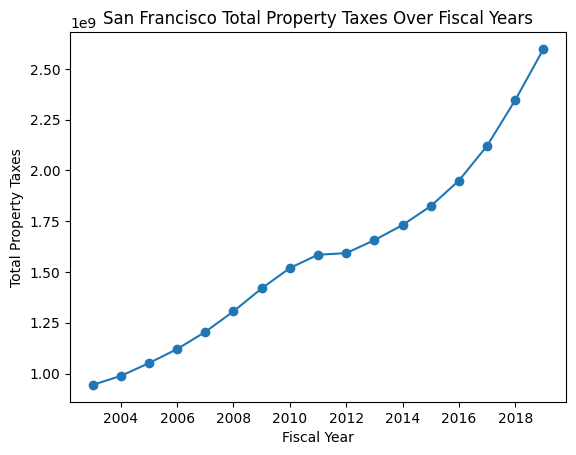

In [100]:
sf_prop = connection.execute("""
SELECT
    "Fiscal Year",
    "Total_Countywide Property Taxes"
FROM property_tax
WHERE "Entity Name" = 'San Francisco';
""").fetchdf()
plt.plot(sf_prop['Fiscal Year'], sf_prop['Total_Countywide Property Taxes'], marker='o')
plt.title('San Francisco Total Property Taxes Over Fiscal Years')
plt.xlabel('Fiscal Year')
plt.ylabel('Total Property Taxes')
plt.show()


## plotting for Sacramento fiscal year

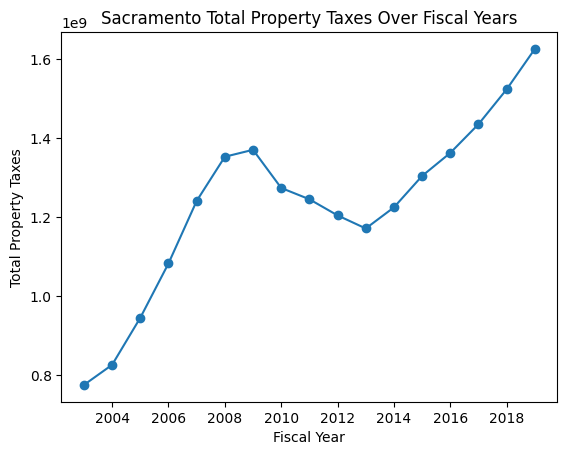

In [99]:
# plotting for Sacramento property tax data
sac_prop = connection.execute("""
SELECT
    "Fiscal Year",
    "Total_Countywide Property Taxes"
FROM property_tax
WHERE "Entity Name" = 'Sacramento';
""").fetchdf()
plt.plot(sac_prop['Fiscal Year'], sac_prop['Total_Countywide Property Taxes'], marker='o')
plt.title('Sacramento Total Property Taxes Over Fiscal Years')
plt.xlabel('Fiscal Year')
plt.ylabel('Total Property Taxes')
plt.show()

# Querying Median Prices
First cell is cleaning alr done by util but I was running into some error with the clean function and did not want to spend more time on that

In [170]:
final = connection.execute("""
SELECT
    EXTRACT(year FROM STRPTIME("Mon-Yr", '%b-%y')) AS Year,
    MEDIAN("CA") AS Median_CA
FROM median_price
GROUP BY Year
ORDER BY Year;
""").fetchdf()

print(final)

    Year  Median_CA
0   1990   193088.0
1   1991   199896.0
2   1992   197315.0
3   1993   188750.0
4   1994   185315.0
5   1995   176608.0
6   1996   177255.5
7   1997   187678.0
8   1998   198186.5
9   1999   218625.0
10  2000   242599.5
11  2001   265216.0
12  2002   322177.5
13  2003   376825.0
14  2004   462540.0
15  2005   538885.0
16  2006   562475.0
17  2007   568605.0
18  2008   364050.0
19  2009   279975.0
20  2010   306075.0
21  2011   288825.0
22  2012   327605.0
23  2013   425315.0
24  2014   451865.0
25  2015   484520.0
26  2016   510990.0
27  2017   546685.0
28  2018   575210.0
29  2019   605480.0
30  2020   646245.0
31  2021   803425.0
32  2022   824010.0
33  2023   827120.0
34  2024   877285.0
35  2025   884350.0


In [171]:
# descriptive stats for CA median price data
stats = connection.execute("""
SELECT
    COUNT("CA") AS count_CA,
    AVG("CA") AS mean_CA,
    STDDEV("CA") AS std_CA,
    MIN("CA") AS min_CA,
    MAX("CA") AS max_CA
FROM median_price
""").fetchdf()
print(stats)

   count_CA        mean_CA         std_CA    min_CA    max_CA
0       428  417058.315421  216220.329607  167790.0  910160.0


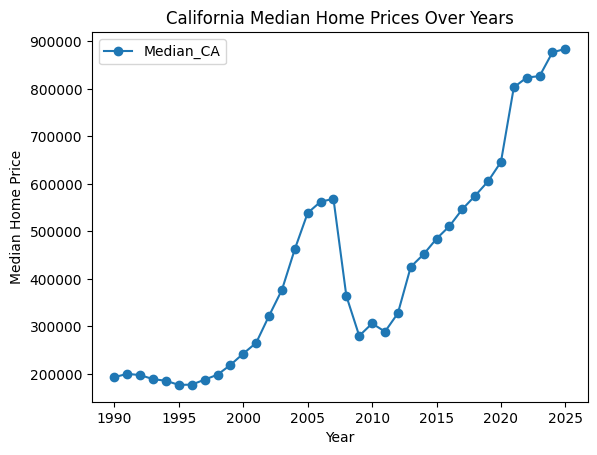

In [150]:
# plot for stat of CA median prices over years
final.plot(x='Year', y='Median_CA', kind='line', marker='o')
plt.title('California Median Home Prices Over Years')
plt.xlabel('Year')
plt.ylabel('Median Home Price')
plt.show()